In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_csv('/telco-churn.csv')

In [ ]:
data.shape

(7043, 21)

**Data Preview**

---
The dataset consists of 7,043 rows and 21 columns. This relatively small size is ideal for our constraint (Real-Time Model / Low Latency), as it requires minimal memory footprint and computational overhead, allowing the system to process data and return predictions in milliseconds.

In [ ]:
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Most features are categorical (object type). To achieve low latency in production, we must encode critical categorical features into numerical values, as string operations degrade real-time performance.

Data Quality Issue: Identified a critical type mismatch in the TotalCharges column. It is parsed as an object (string) instead of a float. This must be converted in the data preparation phase to allow fast mathematical computations.

In [ ]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
data[data['TotalCharges'] == ' ']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


While the standard .isnull().sum() outputs zero missing values across all columns, this is misleading. Based on the TotalCharges type anomaly, missing values are likely hidden as blank string spaces (" "). This hidden missingness must be explicitly handled (imputed with the median) to prevent unexpected crashes and ensure stable latency during real-time inference.

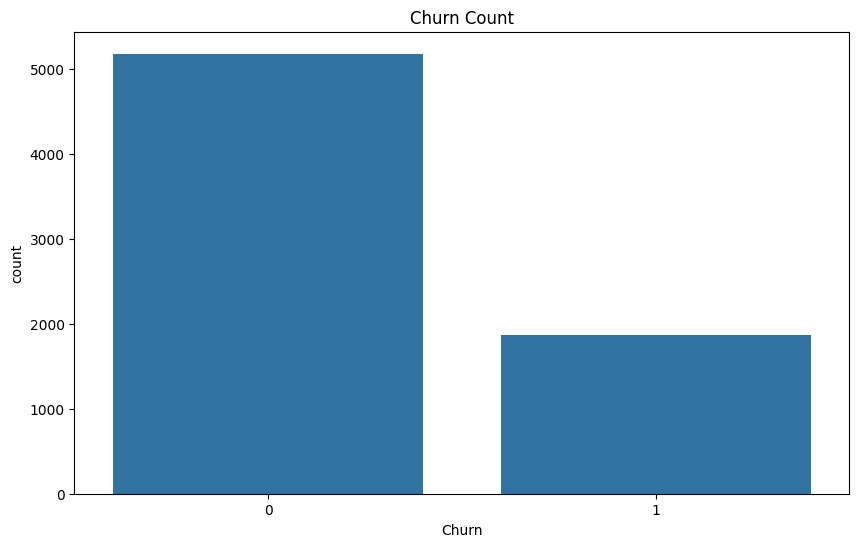

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [ ]:
#churn Distribution Univariate Analysis (Target Variable):
plt.figure(figsize=(10,6))
sns.countplot(x="Churn", data=data)
plt.title("Churn Count")
plt.show()

percentages = data['Churn'].value_counts(normalize=True) * 100

print(percentages)



The count plot and percentage distribution show a clear class imbalance in the target variable (Churn), with 73.5% representing retained customers (No) and 26.5% representing churned customers (Yes). Training a model directly on this skewed data would cause a strong bias toward the majority class, leading the business to miss actual churn risks.

Constraint Alignment (Real-Time Model):

To maintain high accuracy in our real-time, low-latency predictions, we cannot rely on complex runtime threshold adjustments. Instead, we must address this imbalance during the training phase (e.g., using class weights or SMOTE) to ensure the deployed model can instantly and accurately identify the minority class (churners) in milliseconds.

data sampling:

Due to the observed class imbalance in the target variable, a simple random split will not be effective. In the upcoming data preparation phase, we must use Stratified Sampling during the Train/Test split. This ensures that the 73:27 churn ratio is perfectly preserved in our testing environment, allowing us to evaluate our Real-Time Model accurately without bias.

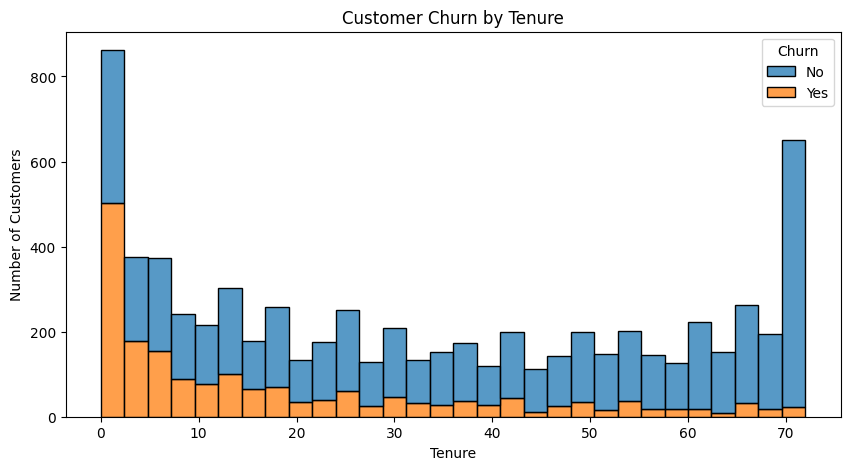

In [ ]:
#Tenure vs. Churn Bivariance Analysis:

plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='tenure', hue='Churn', multiple='stack', bins=30)

plt.title('Customer Churn by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Number of Customers')
plt.show()

The stacked histogram clearly shows that customer churn is highly concentrated in the first few months of subscription (low tenure). As customers stay longer, the churn rate significantly decreases. This indicates that new customers are the most vulnerable and require immediate retention efforts.

**Constraint Alignment (Real-Time Model):**

The tenure variable is a simple integer feature. Relying on it for our Real-Time Model is highly efficient, as it requires no complex transformations or heavy compute. This allows the system to instantly flag new customers with extremely low latency, enabling immediate intervention.

**Data Quality & Bias Assessment:**

The tenure feature contains no mathematical outliers, as the values are naturally bounded (0 to 72 months). This lack of outliers is highly advantageous for our low-latency constraint

the visualization highlights a strong behavioral bias:
churn is heavily skewed towards early-tenure customers, confirming that this feature is a strong, lightweight predictor for real-time risk flagging.

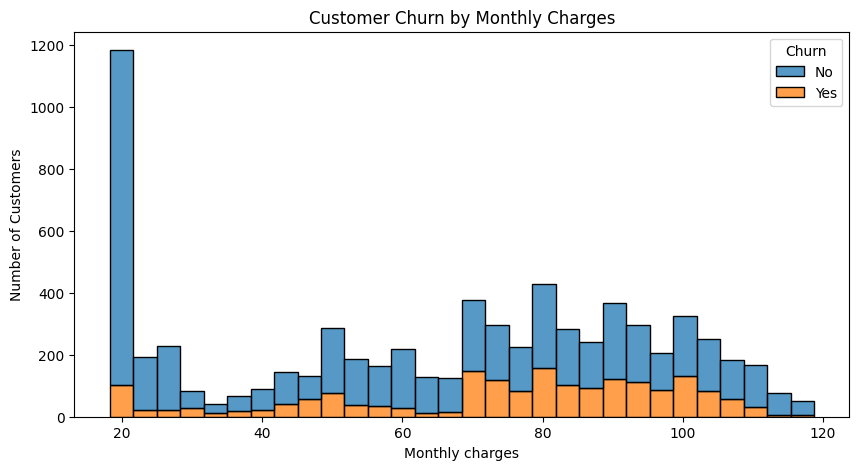

In [ ]:
#Monthly charges vs. Churn Bivariance Analysis:

plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='MonthlyCharges', hue='Churn', multiple='stack', bins=30)

plt.title('Customer Churn by Monthly Charges')
plt.xlabel('Monthly charges')
plt.ylabel('Number of Customers')
plt.show()


The visualization clearly illustrates that churned customers (Yes) are heavily concentrated in the higher monthly charge ranges. This suggests that expensive plans are a primary driver for customer attrition, and the business should focus on retention strategies for high-paying users.

**Constraint Alignment (Real-Time Model):**

The MonthlyCharges feature is continuous (float64). It is highly optimal for our low-latency constraint because it requires zero complex preprocessing or encoding at runtime. The model can instantly ingest this numerical value to generate real-time churn predictions without degrading the system's response time.

**Outliers:**

 No mathematical outliers were detected in the Monthly Charges feature; the data is naturally bounded within expected billing ranges (20–120), which simplifies real-time preprocessing.

**Bias:**

 A significant behavioral bias is observed where churn is heavily concentrated in the higher billing brackets. This confirms that Monthly Charges is a critical and lightweight predictor for identifying high-risk




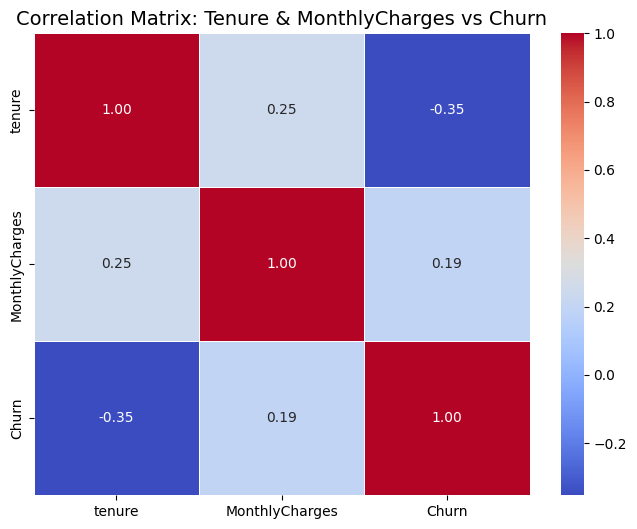

In [ ]:
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

selected_cols = ['tenure', 'MonthlyCharges', 'Churn']
correlation_data = data[selected_cols]


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix: Tenure & MonthlyCharges vs Churn", fontsize=14)
plt.show()

## **Multivariate Analysis (Tenure & MonthlyCharges vs Churn)​**
----

**Strongest Predictors:​**

**Tenure:** Shows a strong negative correlation (-0.35), confirming it as a high-impact feature.​


**Monthly Charges:** Shows a positive correlation (+0.19) with churn.​


**Efficiency:** These features are numerical and "Inference-ready," supporting our Low-Latency requirement.​


**Critical Intersection:** The most "High-Risk" segment is customers with Low Tenure + High Monthly Charges.

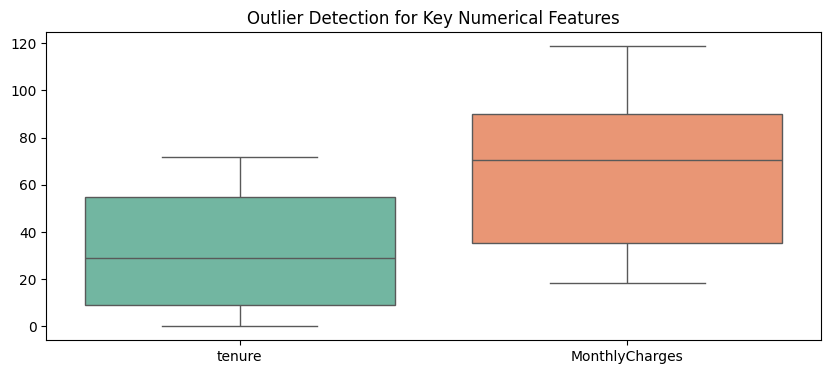

In [ ]:

plt.figure(figsize=(10, 4))
sns.boxplot(data=data[['tenure', 'MonthlyCharges']], palette="Set2")
plt.title("Outlier Detection for Key Numerical Features")
plt.show()


**Visual Evidence:** Boxplot analysis for MonthlyCharges and tenure.

**Observation:** No mathematical or significant outliers detected; data falls within natural business ranges.

**Inference Stability:** The absence of extreme values ensures the model won't produce "Unreliable Predictions" during live operation.

**Constraint Compliance:** Eliminating the need for complex outlier handling at runtime directly supports our Low-Latency requirement.
